<a href="https://colab.research.google.com/github/m-nurbek/diff-rss/blob/main/model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade sympy

In [2]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 11.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
print(np.__version__)
print(pd.__version__)

2.0.2
2.2.2


In [4]:
ap_mean_by_xy_KNN = pd.read_csv("./ap_mean_imputed_KNN.csv")
ap_median_by_xy_KNN = pd.read_csv("./ap_median_imputed_KNN.csv")
ap_mean_by_xy_IDW = pd.read_csv('./ap_mean_by_xy_imputed_IDW.csv')
ap_median_by_xy_IDW = pd.read_csv('./ap_median_by_xy_imputed_IDW.csv')

In [5]:
def plot_RF(floor_df, label):
    fig, ax = plt.subplots()
    ax.scatter(floor_df['X'], floor_df['Y'])
    ax.set_xlabel('X(m)')
    ax.set_ylabel('Y(m)')
    ax.set_title(label)
    plt.show()

In [6]:
# Feature Columns
def get_ap_columns(dataset):
    return [col for col in dataset.columns if col.startswith('AP')]

In [7]:
def plot_indoor_localization_results(true_locations, predicted_locations, title):
    # Plotting
    plt.figure(figsize=(8, 6))

    # Scatter plots for the points
    plt.scatter(true_locations[:, 0], true_locations[:, 1], c='yellow', marker='x', s=100, label="True locations")
    plt.scatter(predicted_locations[:, 0], predicted_locations[:, 1], c='r', alpha=0.5, label="KNN (model trained data)")


    # Draw lines connecting the true points with synthetic predictions
    for i in range(len(true_locations)):
        plt.plot([true_locations[i, 0], predicted_locations[i, 0]],
                [true_locations[i, 1], predicted_locations[i, 1]],
                c='red', linestyle=':', linewidth=1)  # Lines between true and synthetic

    # Labels and title
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()

    # Show the plot
    plt.show()

In [8]:
def subsample_every_n(df, N, origin=(None,None), tol=1e-8):
    """
    Split df into two parts:
      • df_kept: rows where (X−x0) and (Y−y0) are multiples of N
      • df_rest: all the other rows

    Parameters
    ----------
    df : DataFrame with columns 'X','Y'
    N  : float           the grid spacing you want (e.g. 5.0)
    origin : (x0,y0)     the “zero” of your grid; if None, uses (min X, min Y)
    tol : float          tolerance for floating-point modulo

    Returns
    -------
    df_kept, df_rest : DataFrames
    """
    df2 = df.copy()

    # 1) determine grid origin
    x0 = origin[0] if origin[0] is not None else df2['X'].min()
    y0 = origin[1] if origin[1] is not None else df2['Y'].min()

    # 2) compute offsets
    dx = df2['X'] - x0
    dy = df2['Y'] - y0

    # 3) boolean mask for “on-grid” points
    on_grid = (
        np.isclose(dx.mod(N), 0.0, atol=tol) &
        np.isclose(dy.mod(N), 0.0, atol=tol)
    )

    # 4) split
    df_kept = df2.loc[on_grid].reset_index(drop=True)
    df_rest = df2.loc[~on_grid].reset_index(drop=True)

    return df_kept, df_rest

In [9]:
# Define a function to compute the Euclidean distance error.
def compute_localization_errors(true_locations, predicted_locations):
    errors = np.sqrt(np.sum((true_locations - predicted_locations)**2, axis=1))
    return errors

In [10]:
def fraction(actual, orig):
    return actual.shape[0] / orig.shape[0] * 100

# KNN Model Evaluation

In [11]:
cond_cols = ['X','Y']

In [12]:
def knn_evaluation(X_train, X_test, y_train, y_test, plot_label="Localization errors"):
    knn_scaler=StandardScaler()
    X_ap_train_scaled = knn_scaler.fit_transform(X_train)

    # --- Custom Weight Function (1 / distance^2) ---
    def inverse_squared_weight(distances):
        # Avoid division by zero for exact matches
        # (replace 0 with a tiny number)
        distances = np.maximum(distances, 1e-10)
        return 1.0 / (distances ** 2)

    # KNN multi-output
    knn = KNeighborsRegressor(
        weights=inverse_squared_weight,
        metric='manhattan')

    param_grid = {'n_neighbors': range(3, 10)}
    grid_search = GridSearchCV(knn, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_search.fit(X_ap_train_scaled, y_train)
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best score: {grid_search.best_score_}")

    knn_best = grid_search.best_estimator_

    pred_locations_test = knn_best.predict(knn_scaler.transform(X_test))

    print(f"Localization Error: {np.mean(compute_localization_errors(y_test, pred_locations_test))}")

    plot_indoor_localization_results(y_test, pred_locations_test, plot_label)

In [13]:
def evaluate_knn(train_dataset, test_dataset, plot_label="Localization errors"):
    X_ap_train = train_dataset[get_ap_columns(train_dataset)].values
    y_xy_train = train_dataset[cond_cols].values

    X_ap_test = test_dataset[get_ap_columns(test_dataset)].values
    y_xy_test = test_dataset[cond_cols].values

    knn_evaluation(X_ap_train, X_ap_test, y_xy_train, y_xy_test, plot_label=plot_label)

### 100% of the dataset

Best parameters: {'n_neighbors': 3}
Best score: -3.779251392651481
Localization Error: 0.0


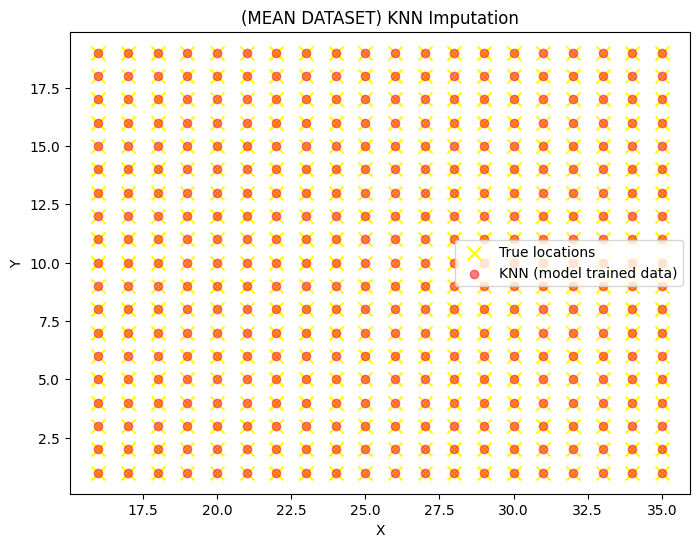

Best parameters: {'n_neighbors': 5}
Best score: -3.7080705038231456
Localization Error: 0.0


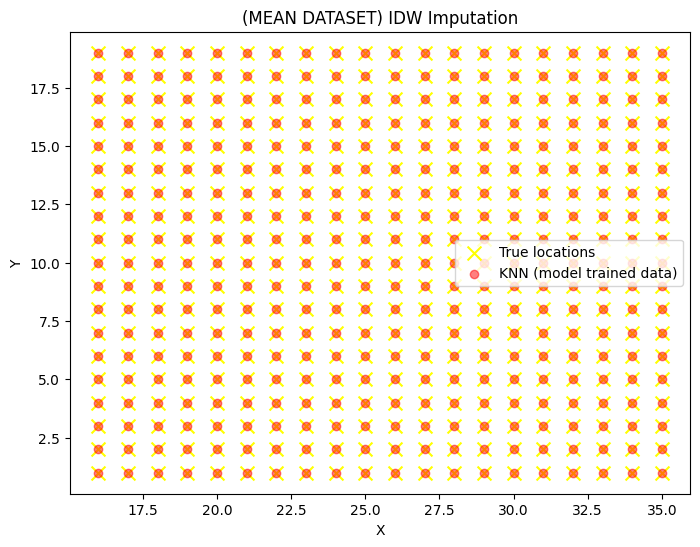

Best parameters: {'n_neighbors': 5}
Best score: -3.758143620771767
Localization Error: 0.0


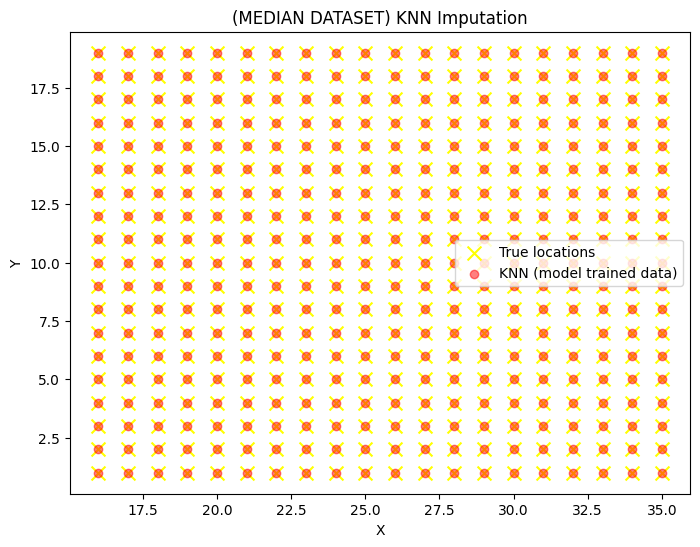

Best parameters: {'n_neighbors': 4}
Best score: -3.7493443919509972
Localization Error: 0.0


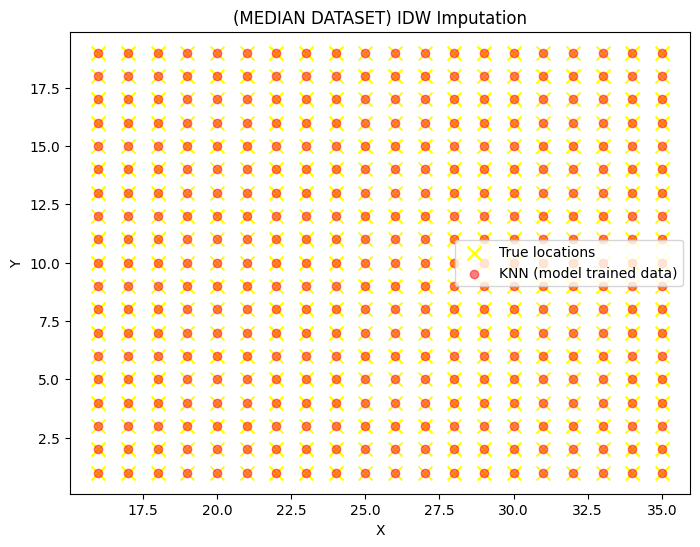

In [14]:
evaluate_knn(ap_mean_by_xy_KNN, ap_mean_by_xy_KNN, plot_label="(MEAN DATASET) KNN Imputation")
evaluate_knn(ap_mean_by_xy_IDW, ap_mean_by_xy_IDW, plot_label="(MEAN DATASET) IDW Imputation")
evaluate_knn(ap_median_by_xy_KNN, ap_median_by_xy_KNN, plot_label="(MEDIAN DATASET) KNN Imputation")
evaluate_knn(ap_median_by_xy_IDW, ap_median_by_xy_IDW, plot_label="(MEDIAN DATASET) IDW Imputation")

### Every 2nd

In [15]:
class SPLITTED_DATASET:
    def __init__(self, mean_knn_split, median_knn_split, mean_IDW_split, median_IDW_split):
        self.mean_knn_split = mean_knn_split
        self.median_knn_split = median_knn_split
        self.mean_IDW_split = mean_IDW_split
        self.median_IDW_split = median_IDW_split

In [16]:
def evaluate_knn_prediction(choose_n):
    CHOOSE_N = choose_n

    training_df_mean_KNN, test_df_mean_KNN = subsample_every_n(ap_mean_by_xy_KNN, CHOOSE_N, (0,0))
    training_df_median_KNN, test_df_median_KNN = subsample_every_n(ap_mean_by_xy_KNN, CHOOSE_N, (0,0))
    training_df_mean_IDW, test_df_mean_IDW = subsample_every_n(ap_mean_by_xy_IDW, CHOOSE_N, (0,0))
    training_df_median_IDW, test_df_median_IDW = subsample_every_n(ap_median_by_xy_IDW, CHOOSE_N, (0,0))

    print(f"Fraction (original mean): {fraction(training_df_mean_KNN, ap_mean_by_xy_KNN)}")
    print(f"Fraction (original median): {fraction(training_df_median_KNN, ap_median_by_xy_KNN)}")
    print(f"Fraction (imputed mean): {fraction(training_df_mean_IDW, ap_mean_by_xy_IDW)}")
    print(f"Fraction (imputed median: {fraction(training_df_median_IDW, ap_median_by_xy_IDW)}")

    plot_RF(training_df_mean_KNN, "Every 3rd (9% of the dataset)")

    evaluate_knn(training_df_mean_KNN, test_df_mean_KNN, plot_label="(MEAN DATASET) KNN Imputation")
    evaluate_knn(training_df_mean_IDW, test_df_mean_IDW, plot_label="(MEAN DATASET) IDW Imputation")
    evaluate_knn(training_df_median_KNN, test_df_median_KNN, plot_label="(MEDIAN DATASET) KNN Imputation")
    evaluate_knn(training_df_median_IDW, test_df_median_IDW, plot_label="(MEDIAN DATASET) IDW Imputation")

    return SPLITTED_DATASET(
        mean_knn_split=(training_df_mean_KNN, test_df_mean_KNN),
        median_knn_split=(training_df_median_KNN, test_df_median_KNN),
        mean_IDW_split=(training_df_mean_IDW, test_df_mean_IDW),
        median_IDW_split=(training_df_median_IDW, test_df_median_IDW)
    )

Fraction (original mean): 23.684210526315788
Fraction (original median): 23.684210526315788
Fraction (imputed mean): 23.684210526315788
Fraction (imputed median: 23.684210526315788


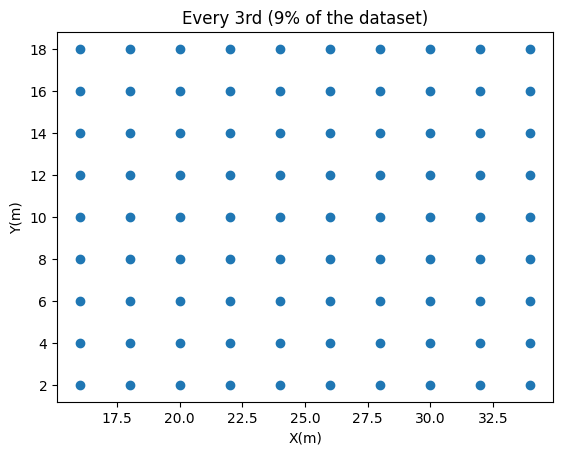

Best parameters: {'n_neighbors': 3}
Best score: -4.245570606853486
Localization Error: 2.5801865079774156


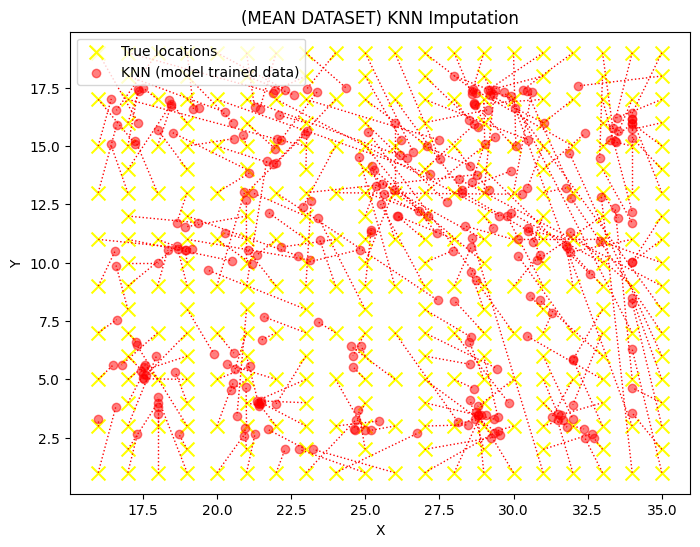

Best parameters: {'n_neighbors': 3}
Best score: -4.09146614606695
Localization Error: 2.4119599216991574


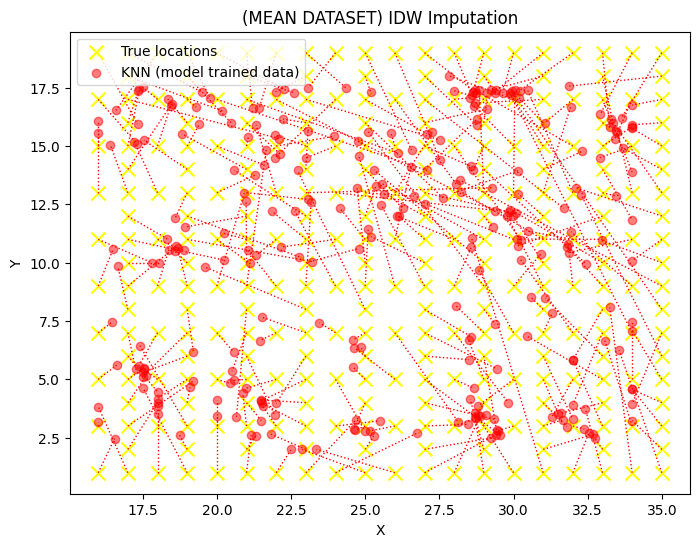

Best parameters: {'n_neighbors': 3}
Best score: -4.245570606853486
Localization Error: 2.5801865079774156


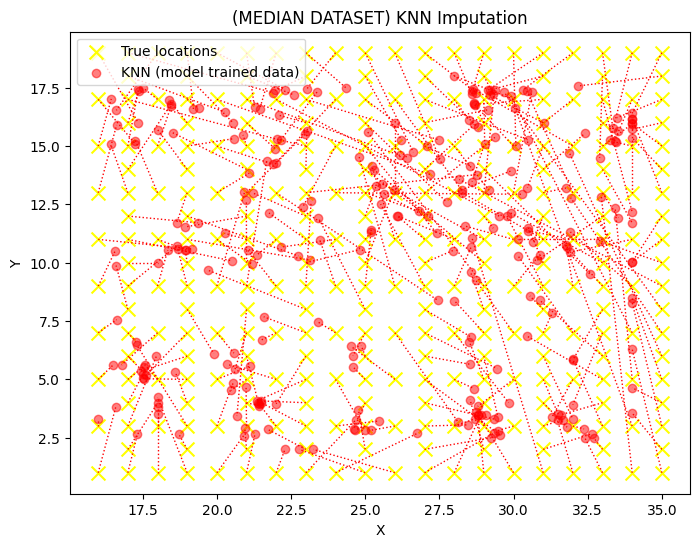

Best parameters: {'n_neighbors': 3}
Best score: -4.052630230103023
Localization Error: 3.013780750868845


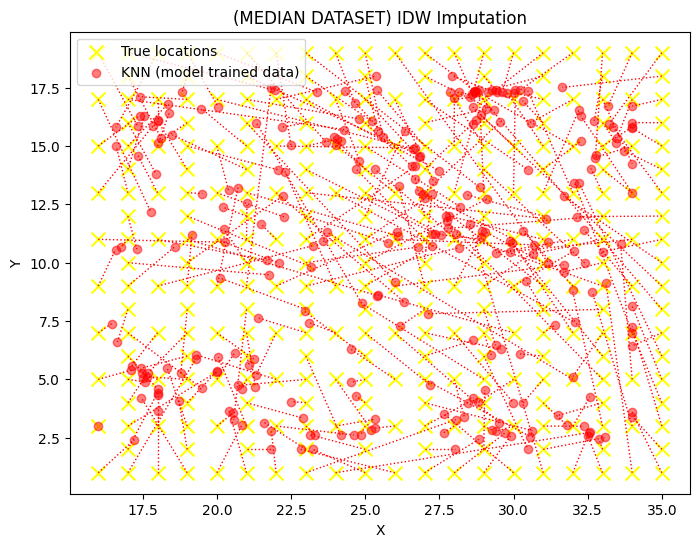

In [17]:
split_every_2nd = evaluate_knn_prediction(2)

### Every 3rd

Fraction (original mean): 9.473684210526317
Fraction (original median): 9.473684210526317
Fraction (imputed mean): 9.473684210526317
Fraction (imputed median: 9.473684210526317


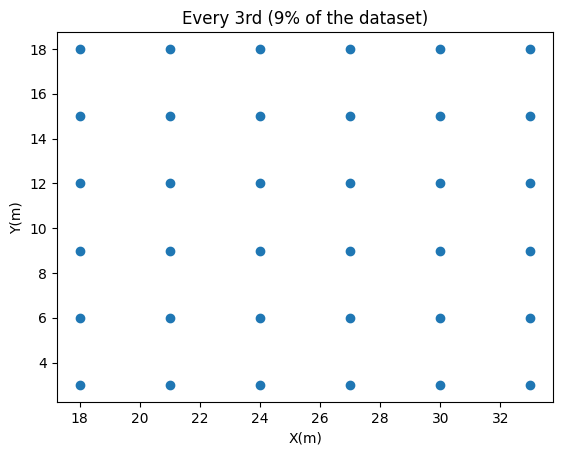

Best parameters: {'n_neighbors': 3}
Best score: -3.8158507757246767
Localization Error: 3.3136101063055587


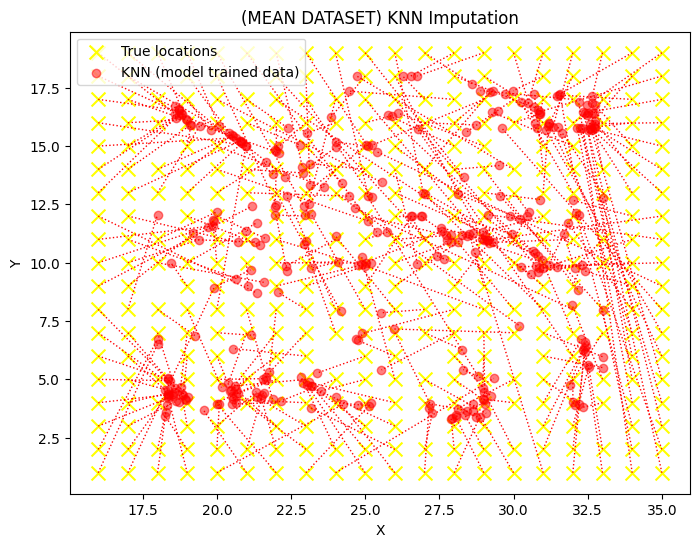

Best parameters: {'n_neighbors': 3}
Best score: -3.751917733499603
Localization Error: 3.269735612023027


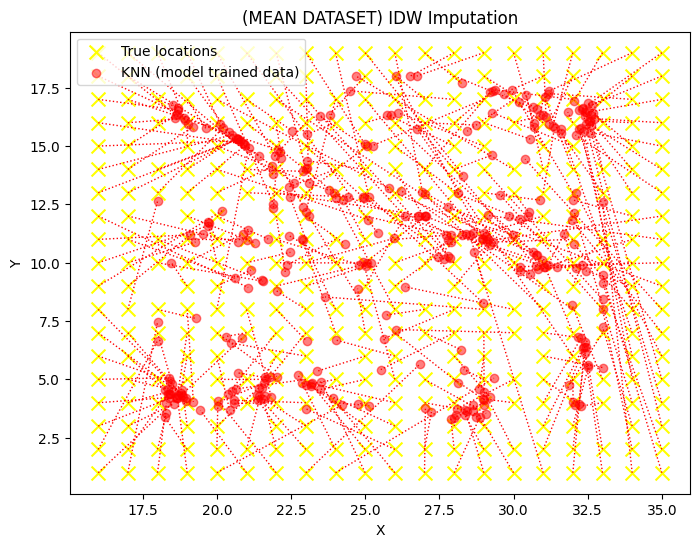

Best parameters: {'n_neighbors': 3}
Best score: -3.8158507757246767
Localization Error: 3.3136101063055587


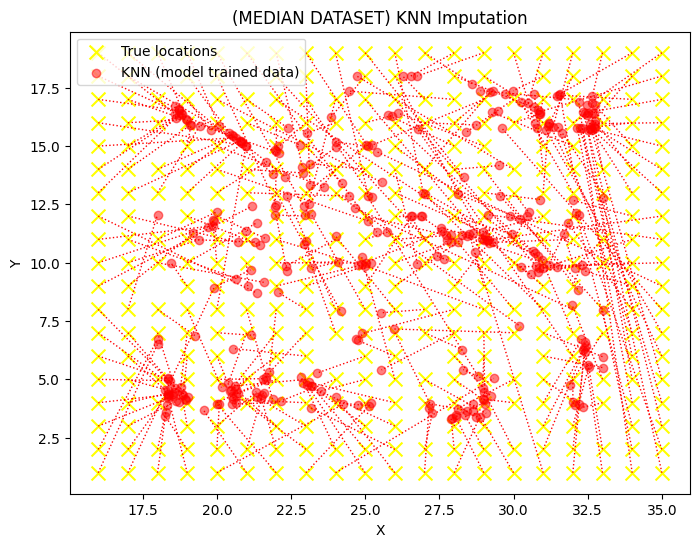

Best parameters: {'n_neighbors': 3}
Best score: -3.7898643804357603
Localization Error: 3.630416737370469


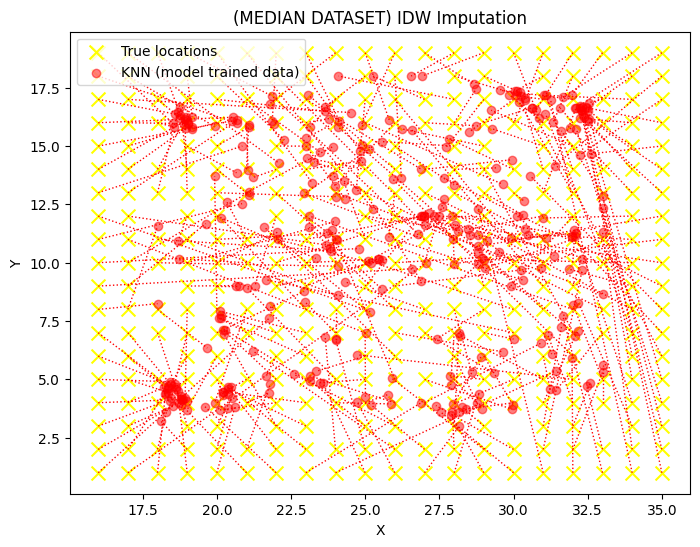

In [18]:
split_every_3rd = evaluate_knn_prediction(3)

### Every 4th

Fraction (original mean): 5.263157894736842
Fraction (original median): 5.263157894736842
Fraction (imputed mean): 5.263157894736842
Fraction (imputed median: 5.263157894736842


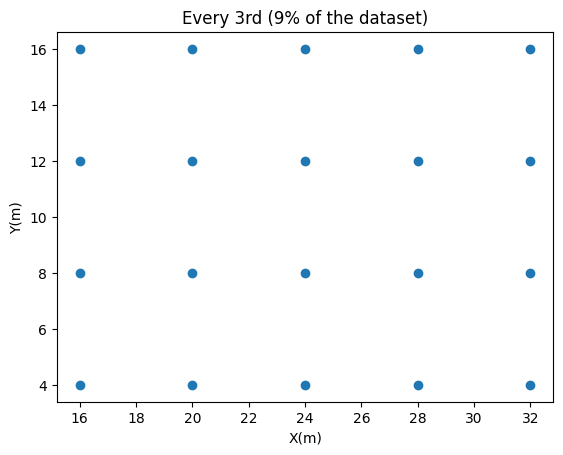

Best parameters: {'n_neighbors': 3}
Best score: -4.330689500243259
Localization Error: 3.740915849329978


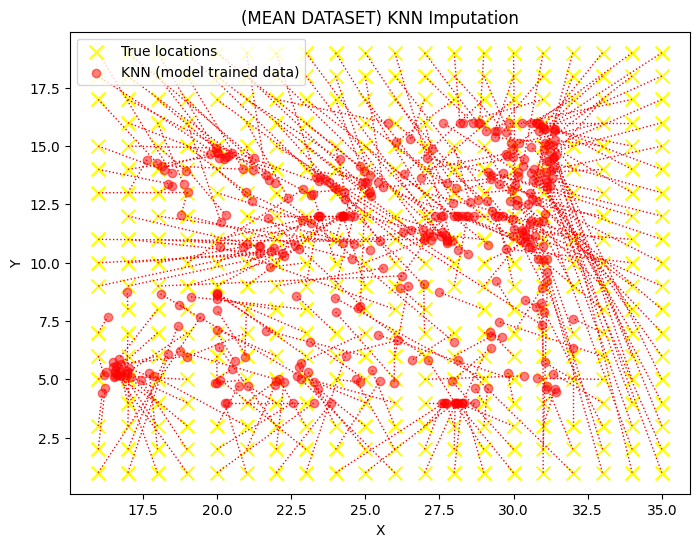

Best parameters: {'n_neighbors': 3}
Best score: -3.902590138994405
Localization Error: 3.68155554183252


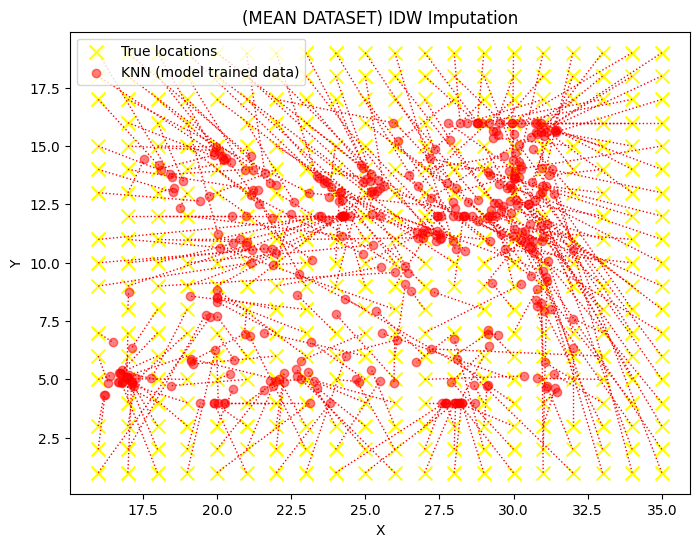

Best parameters: {'n_neighbors': 3}
Best score: -4.330689500243259
Localization Error: 3.740915849329978


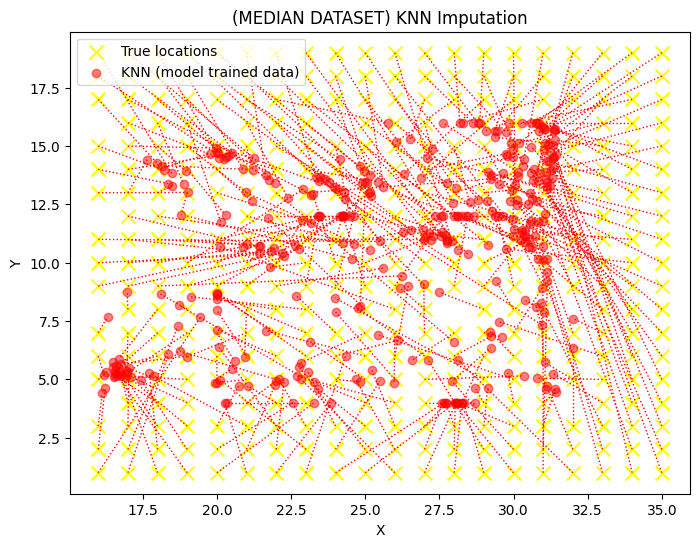

Best parameters: {'n_neighbors': 5}
Best score: -4.328919478490903
Localization Error: 4.285314412693964


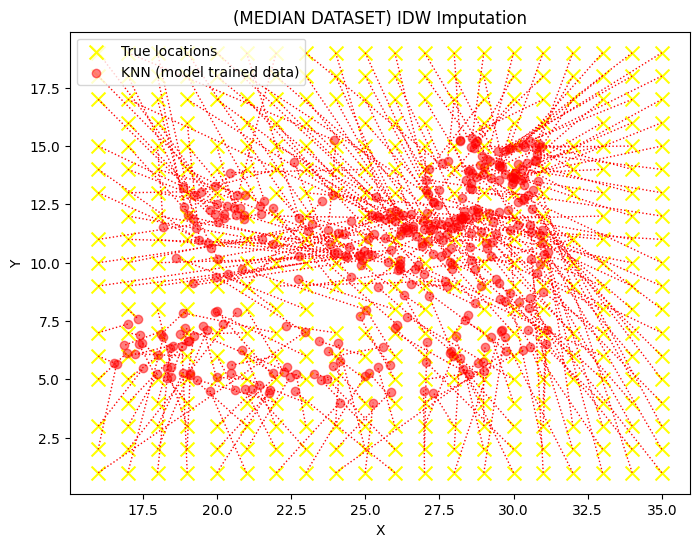

In [19]:
split_every_4th = evaluate_knn_prediction(4)

### Every 5th

Fraction (original mean): 3.1578947368421053
Fraction (original median): 3.1578947368421053
Fraction (imputed mean): 3.1578947368421053
Fraction (imputed median: 3.1578947368421053


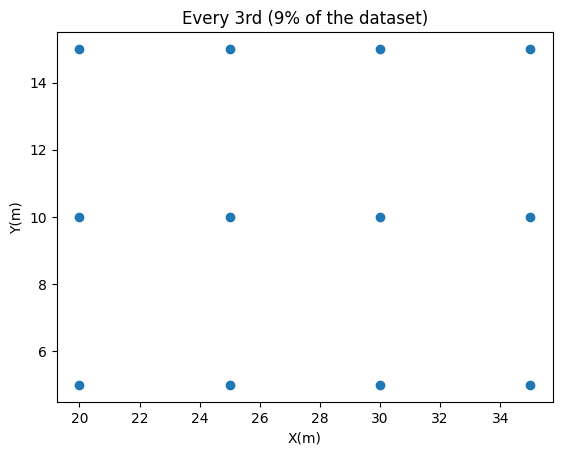

Best parameters: {'n_neighbors': 3}
Best score: -4.272462513809537
Localization Error: 5.2390060164582595


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-4.27246251 -4.59923246 -4.7065658  -4.64340357 -4.71640551 -4.79691668
         nan]
  warnings.warn(


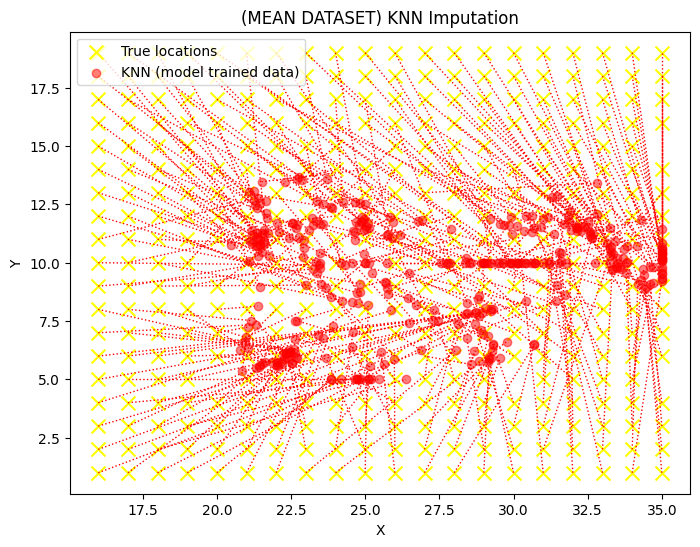

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-4.04360333 -4.42877964 -4.42802016 -4.54669851 -4.57795113 -4.69505106
         nan]
  warnings.warn(


Best parameters: {'n_neighbors': 3}
Best score: -4.043603333960093
Localization Error: 5.00657361801822


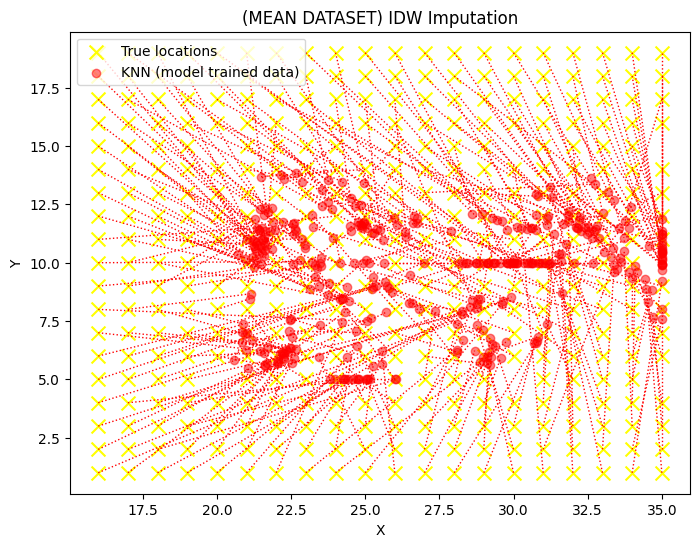

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-4.27246251 -4.59923246 -4.7065658  -4.64340357 -4.71640551 -4.79691668
         nan]
  warnings.warn(


Best parameters: {'n_neighbors': 3}
Best score: -4.272462513809537
Localization Error: 5.2390060164582595


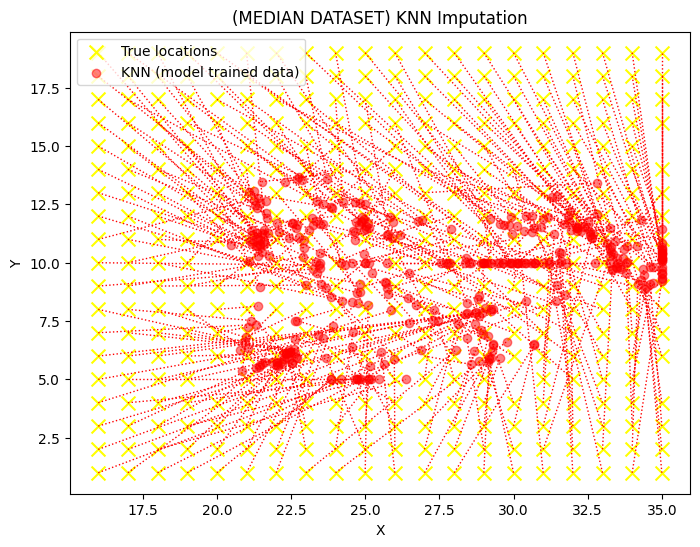

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-4.58809836 -4.65155146 -4.70099863 -4.75085276 -4.7963108  -4.88271571
         nan]
  warnings.warn(


Best parameters: {'n_neighbors': 3}
Best score: -4.588098360756553
Localization Error: 5.375975469365592


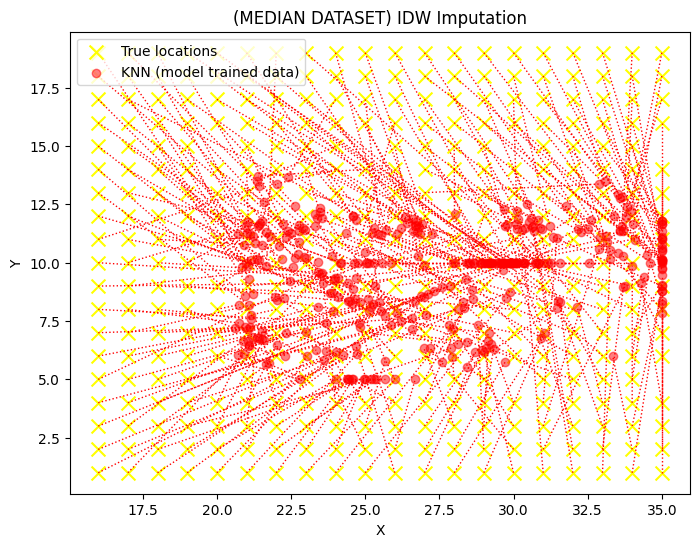

In [20]:
split_every_5th = evaluate_knn_prediction(5)

---

# Table Diffusion Model

In [21]:
def get_beta(t: int, T: int) -> float:
    return (1.0 - math.cos(math.pi * t / T)) / 2.0

def timestep_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=timesteps.device) / max(half - 1, 1))
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = nn.functional.pad(emb, (0, 1))
    return emb

# Tabular U-Net-like MLP backbone
class TabularUNet(nn.Module):
    def __init__(self, input_dim: int, cond_dim: int, time_emb_dim: int, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        # Heads for time and condition
        self.t_proj = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, hidden[0])
        )
        self.c_proj = nn.Sequential(
            nn.Linear(cond_dim, hidden[0]),
            nn.SiLU()
        )

        # Encoder blocks
        enc_dims = [input_dim + hidden[0]*2] + hidden[:-1]
        self.encoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i, o), nn.SiLU())
            for i, o in zip(enc_dims, hidden))

        # Decoder blocks
        dec_dims = hidden[::-1]
        self.decoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i*2, o), nn.SiLU())
            for i, o in zip(dec_dims[:-1], dec_dims[1:]))

        # Final layer
        self.out = nn.Linear(hidden[0], input_dim)

    def forward(self, x: torch.Tensor, cond: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        # x: [batch, input_dim]
        # cond: [batch, cond_dim]
        # t_emb: [batch, time_emb_dim]
        t_h = self.t_proj(t_emb)
        c_h = self.c_proj(cond)

        h = torch.cat([x, c_h, t_h], dim=1)
        skips = []
        # Encode
        for enc in self.encoder:
            h = enc(h)
            skips.append(h)
        # Decode
        for dec in self.decoder:
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = dec(h)
        return self.out(h)

# Diffusion model with Tabular U-Net backbone
class TableDiffusion(nn.Module):
    def __init__(self, rss_dim: int, cond_dim: int = 2, time_emb_dim: int = 128, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.unet = TabularUNet(
            rss_dim,
            cond_dim,
            time_emb_dim,
            hidden
        )

    def forward(self, noised_rss: torch.Tensor, cond: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = timestep_embedding(t, self.time_emb_dim)
        return self.unet(noised_rss, cond, t_emb)


# Training loop (noise-prediction objective)
def train_table_diffusion(
    model: TableDiffusion,
    X_cond: torch.Tensor,
    Y_rss: torch.Tensor,
    steps: int = 100,
    batch_size: int = 64,
    epochs: int = 100,
    lr: float = 6e-4,
):
    device = (
        torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.to(device)
    ds = torch.utils.data.TensorDataset(X_cond, Y_rss)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    model.train()

    for ep in range(1, epochs+1):
        total = 0.0
        model.train()
        for cond_b, rss_b in dl:
            cond_b, rss_b = cond_b.to(device), rss_b.to(device)
            loss_acc = 0.0
            for t in range(steps):
                beta = get_beta(t, steps)
                noise = torch.randn_like(rss_b) * math.sqrt(beta)
                x_t = rss_b + noise
                t_vec = torch.full((rss_b.size(0),), t, dtype=torch.long, device=device)
                pred = model(x_t, cond_b, t_vec)
                loss_acc += mse(pred, noise)
            loss = loss_acc / steps
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        if ep % 10 == 0 or ep == 1:
            print(f"[TableDiffusion] Epoch {ep}/{epochs} - loss: {total/len(dl):.4f}")
    return model

# Reverse sampling (denoise from Gaussian)
def sample_table_diffusion(
        model: TableDiffusion,
        X_cond: torch.Tensor,
        diffusion_steps: int = 100
) -> np.ndarray:
    device = (
    torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.eval()
    X_cond = X_cond.to(device)
    print(X_cond.shape)
    n, _ = X_cond.shape
    rss_dim = model.unet.out.out_features
    samples = torch.randn(n, rss_dim, device=device)

    with torch.no_grad():
        for t in reversed(range(diffusion_steps)):
            beta = get_beta(t, diffusion_steps)
            t_vec = torch.full((n,), t, dtype=torch.long, device=device)
            pred_eps = model(samples, X_cond, t_vec)
            samples = samples - pred_eps * math.sqrt(beta)
        return samples.cpu().numpy()

# Validation noise-prediction loss (quick proxy)
def eval_noise_mse(model, Xc, Yr, steps=50):
    device = next(model.parameters()).device
    mse = nn.MSELoss()
    model.eval()
    with torch.no_grad():
        Xc, Yr = Xc.to(device), Yr.to(device)
        tot = 0.0
        for t in range(steps):
            beta = get_beta(t, steps)
            eps = torch.randn_like(Yr) * math.sqrt(beta)
            x_t = Yr + eps
            t_vec = torch.full((Yr.size(0),), t, dtype=torch.long, device=device)
            pred = model(x_t, Xc, t_vec)
            tot += mse(pred, eps).item()
        return tot / steps

In [22]:
def train_tdm(dataset, ap_cols, cond_cols, steps=75, batch_size=64, epochs=200, lr=6.3e-4):
    # Replace missing APs with a sentinel before scaling
    td_train_filled = dataset.copy()
    td_train_filled[ap_cols] = td_train_filled[ap_cols].fillna(-110)

    # Train/val/test split
    X_cond = td_train_filled[cond_cols].values.astype("float32")
    Y_rss = td_train_filled[ap_cols].values.astype("float32")

    # Scale RSS targets only
    rss_scaler = StandardScaler()
    Y_rss_s = rss_scaler.fit_transform(Y_rss)

    print(f"Y_rss.shape: {Y_rss_s.shape}")

    # Tensors for X
    X_cond_t  = torch.tensor(X_cond,   dtype=torch.float32)
    # Tensors for Y
    Y_rss_t  = torch.tensor(Y_rss_s, dtype=torch.float32)

    # Instantiate, train, and demonstrate generation at custom coordinates
    rss_dim = len(ap_cols)
    td_model = TableDiffusion(rss_dim=rss_dim, cond_dim=2, time_emb_dim=128)

    td_model = train_table_diffusion(
        td_model,
        X_cond_t,
        Y_rss_t,
        steps=steps,          # can tune (e.g., 50–200)
        batch_size=batch_size,
        epochs=epochs,        # can tune
        lr=lr
    )

    val_noise_mse = eval_noise_mse(td_model, X_cond_t, Y_rss_t, steps=50)
    print(f"[TableDiffusion] Validation noise-prediction MSE: {val_noise_mse:.4f}")

    return td_model, rss_scaler, X_cond_t, Y_rss_t


In [23]:
def generate_rss_values(model, coords_dataset, rss_scaler, ap_cols, diffusion_steps=100):
    """
    Generate synthetic RSS values for the given condition columns.
    """

    gen_rss_values = sample_table_diffusion(model, coords_dataset, diffusion_steps)

    # Inverse transform to get the RSS values in the original scale
    synthetic_rss = rss_scaler.inverse_transform(gen_rss_values)

    synthetic_rss_df = pd.DataFrame(synthetic_rss, columns=ap_cols)
    return synthetic_rss_df

def generate_synthetic_rss(td_model, scaler, coordinates, ap_cols, diffusion_steps=100):
    coords_t = torch.tensor(coordinates.values,  dtype=torch.float32)
    synthetic_rss  = generate_rss_values(td_model, coords_t, scaler, ap_cols, diffusion_steps=diffusion_steps)

    synthetic_dataset = pd.concat([synthetic_rss, coordinates], axis=1)
    return synthetic_dataset

---

In [24]:
def evaluate_tdm_prediction(train_dataset, test_dataset, epochs=250, batch_size=64, diffusion_steps=100):
    training_df = train_dataset.copy()
    test_df = test_dataset.copy()

    tdm_model, scaler_tdm, _, _ = train_tdm(
            training_df,
            ap_cols=get_ap_columns(training_df),
            cond_cols=['X','Y'],
            epochs=epochs,
            batch_size=batch_size
    )

    synthetic_df = generate_synthetic_rss(
        td_model=tdm_model,
        scaler=scaler_tdm,
        coordinates=test_df[['X','Y']],
        ap_cols=get_ap_columns(test_df),
        diffusion_steps=diffusion_steps
    )

    X_ap_train = training_df[get_ap_columns(training_df)].values
    y_xy_train = training_df[['X','Y']].values

    X_ap_test = test_df[get_ap_columns(test_df)].values
    y_xy_test = test_df[['X','Y']].values

    X_ap_synth = synthetic_df[get_ap_columns(synthetic_df)].values
    y_xy_synth = synthetic_df[['X','Y']].values

    X_combined = pd.concat([pd.DataFrame(X_ap_train), pd.DataFrame(X_ap_synth)], axis=0).values
    y_combined = pd.concat([pd.DataFrame(y_xy_train), pd.DataFrame(y_xy_synth)], axis=0).values

    knn_evaluation(X_combined, X_ap_test, y_combined, y_xy_test)

Y_rss.shape: (90, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5200
[TableDiffusion] Epoch 10/4000 - loss: 0.4965
[TableDiffusion] Epoch 20/4000 - loss: 0.4847
[TableDiffusion] Epoch 30/4000 - loss: 0.4663
[TableDiffusion] Epoch 40/4000 - loss: 0.4623
[TableDiffusion] Epoch 50/4000 - loss: 0.4338
[TableDiffusion] Epoch 60/4000 - loss: 0.4458
[TableDiffusion] Epoch 70/4000 - loss: 0.4525
[TableDiffusion] Epoch 80/4000 - loss: 0.3971
[TableDiffusion] Epoch 90/4000 - loss: 0.3378
[TableDiffusion] Epoch 100/4000 - loss: 0.3330
[TableDiffusion] Epoch 110/4000 - loss: 0.3094
[TableDiffusion] Epoch 120/4000 - loss: 0.2892
[TableDiffusion] Epoch 130/4000 - loss: 0.2111
[TableDiffusion] Epoch 140/4000 - loss: 0.1895
[TableDiffusion] Epoch 150/4000 - loss: 0.1821
[TableDiffusion] Epoch 160/4000 - loss: 0.1561
[TableDiffusion] Epoch 170/4000 - loss: 0.1560
[TableDiffusion] Epoch 180/4000 - loss: 0.1465
[TableDiffusion] Epoch 190/4000 - loss: 0.1341
[TableDiffusion] Epoch 200/4000 - lo

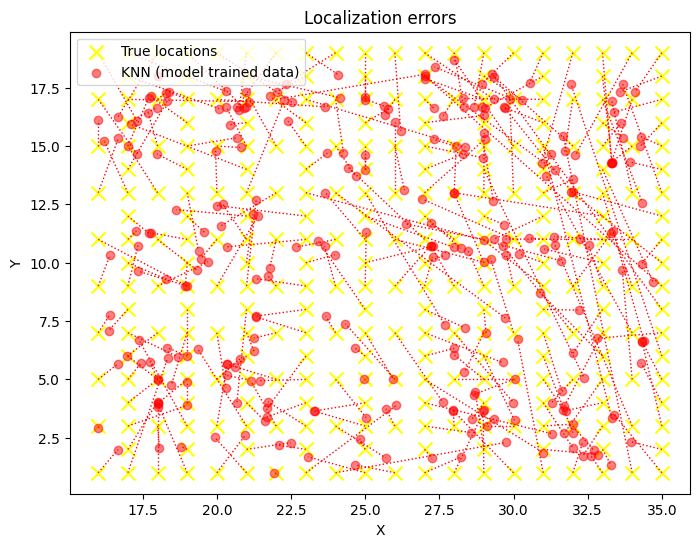

Y_rss.shape: (36, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5033
[TableDiffusion] Epoch 10/4000 - loss: 0.4898
[TableDiffusion] Epoch 20/4000 - loss: 0.4969
[TableDiffusion] Epoch 30/4000 - loss: 0.4923
[TableDiffusion] Epoch 40/4000 - loss: 0.4794
[TableDiffusion] Epoch 50/4000 - loss: 0.4794
[TableDiffusion] Epoch 60/4000 - loss: 0.4635
[TableDiffusion] Epoch 70/4000 - loss: 0.4512
[TableDiffusion] Epoch 80/4000 - loss: 0.4511
[TableDiffusion] Epoch 90/4000 - loss: 0.4171
[TableDiffusion] Epoch 100/4000 - loss: 0.4737
[TableDiffusion] Epoch 110/4000 - loss: 0.4633
[TableDiffusion] Epoch 120/4000 - loss: 0.4387
[TableDiffusion] Epoch 130/4000 - loss: 0.3923
[TableDiffusion] Epoch 140/4000 - loss: 0.3855
[TableDiffusion] Epoch 150/4000 - loss: 0.3540
[TableDiffusion] Epoch 160/4000 - loss: 0.3560
[TableDiffusion] Epoch 170/4000 - loss: 0.3147
[TableDiffusion] Epoch 180/4000 - loss: 0.3823
[TableDiffusion] Epoch 190/4000 - loss: 0.3776
[TableDiffusion] Epoch 200/4000 - lo

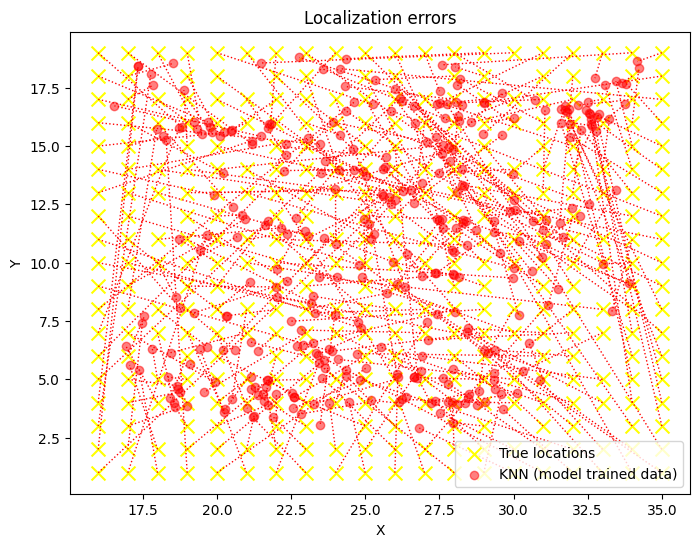

Y_rss.shape: (20, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5068
[TableDiffusion] Epoch 10/4000 - loss: 0.4965
[TableDiffusion] Epoch 20/4000 - loss: 0.4939
[TableDiffusion] Epoch 30/4000 - loss: 0.4880
[TableDiffusion] Epoch 40/4000 - loss: 0.4809
[TableDiffusion] Epoch 50/4000 - loss: 0.4762
[TableDiffusion] Epoch 60/4000 - loss: 0.4590
[TableDiffusion] Epoch 70/4000 - loss: 0.4537
[TableDiffusion] Epoch 80/4000 - loss: 0.4541
[TableDiffusion] Epoch 90/4000 - loss: 0.4267
[TableDiffusion] Epoch 100/4000 - loss: 0.4453
[TableDiffusion] Epoch 110/4000 - loss: 0.3799
[TableDiffusion] Epoch 120/4000 - loss: 0.4300
[TableDiffusion] Epoch 130/4000 - loss: 0.4038
[TableDiffusion] Epoch 140/4000 - loss: 0.3483
[TableDiffusion] Epoch 150/4000 - loss: 0.3452
[TableDiffusion] Epoch 160/4000 - loss: 0.3555
[TableDiffusion] Epoch 170/4000 - loss: 0.3099
[TableDiffusion] Epoch 180/4000 - loss: 0.3604
[TableDiffusion] Epoch 190/4000 - loss: 0.3030
[TableDiffusion] Epoch 200/4000 - lo

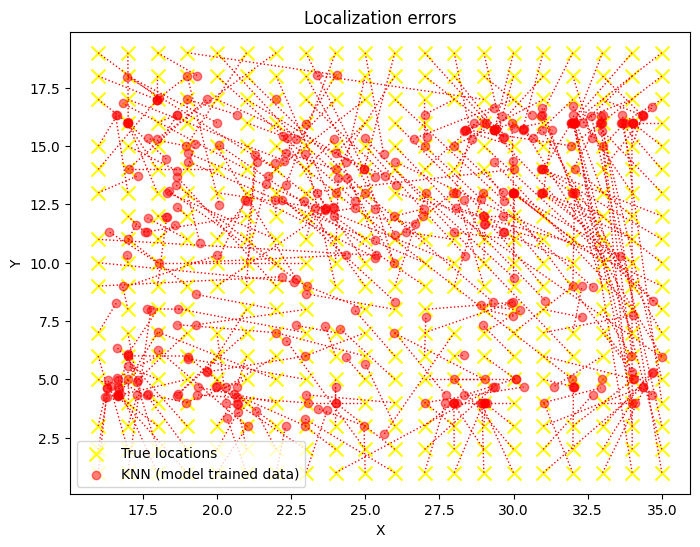

Y_rss.shape: (12, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5070
[TableDiffusion] Epoch 10/4000 - loss: 0.4982
[TableDiffusion] Epoch 20/4000 - loss: 0.5035
[TableDiffusion] Epoch 30/4000 - loss: 0.4742
[TableDiffusion] Epoch 40/4000 - loss: 0.4924
[TableDiffusion] Epoch 50/4000 - loss: 0.4810
[TableDiffusion] Epoch 60/4000 - loss: 0.4671
[TableDiffusion] Epoch 70/4000 - loss: 0.4561
[TableDiffusion] Epoch 80/4000 - loss: 0.4805
[TableDiffusion] Epoch 90/4000 - loss: 0.4376
[TableDiffusion] Epoch 100/4000 - loss: 0.4559
[TableDiffusion] Epoch 110/4000 - loss: 0.4122
[TableDiffusion] Epoch 120/4000 - loss: 0.4208
[TableDiffusion] Epoch 130/4000 - loss: 0.3973
[TableDiffusion] Epoch 140/4000 - loss: 0.3612
[TableDiffusion] Epoch 150/4000 - loss: 0.3934
[TableDiffusion] Epoch 160/4000 - loss: 0.3511
[TableDiffusion] Epoch 170/4000 - loss: 0.3385
[TableDiffusion] Epoch 180/4000 - loss: 0.3482
[TableDiffusion] Epoch 190/4000 - loss: 0.3045
[TableDiffusion] Epoch 200/4000 - lo

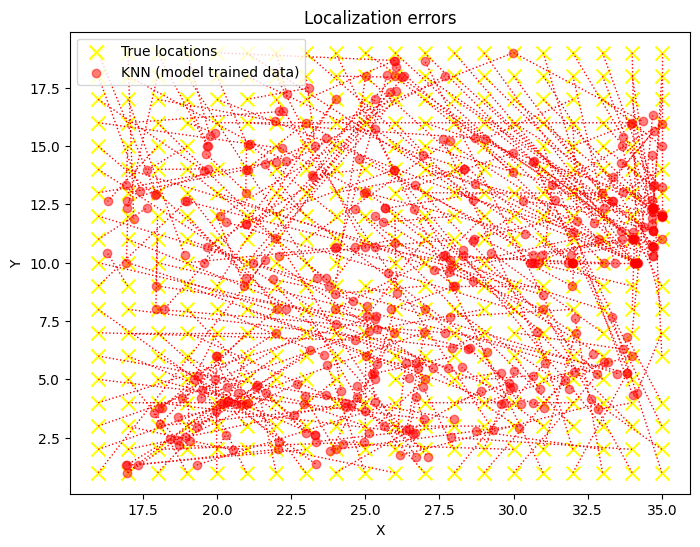

In [25]:
evaluate_tdm_prediction(
    split_every_2nd.mean_knn_split[0],
    split_every_2nd.mean_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_3rd.mean_knn_split[0],
    split_every_3rd.mean_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_4th.mean_knn_split[0],
    split_every_4th.mean_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_5th.mean_knn_split[0],
    split_every_5th.mean_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)


Y_rss.shape: (90, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5185
[TableDiffusion] Epoch 10/4000 - loss: 0.4903
[TableDiffusion] Epoch 20/4000 - loss: 0.4845
[TableDiffusion] Epoch 30/4000 - loss: 0.4576
[TableDiffusion] Epoch 40/4000 - loss: 0.4797
[TableDiffusion] Epoch 50/4000 - loss: 0.4797
[TableDiffusion] Epoch 60/4000 - loss: 0.4466
[TableDiffusion] Epoch 70/4000 - loss: 0.4037
[TableDiffusion] Epoch 80/4000 - loss: 0.3684
[TableDiffusion] Epoch 90/4000 - loss: 0.3173
[TableDiffusion] Epoch 100/4000 - loss: 0.2601
[TableDiffusion] Epoch 110/4000 - loss: 0.2625
[TableDiffusion] Epoch 120/4000 - loss: 0.2194
[TableDiffusion] Epoch 130/4000 - loss: 0.1791
[TableDiffusion] Epoch 140/4000 - loss: 0.1590
[TableDiffusion] Epoch 150/4000 - loss: 0.1531
[TableDiffusion] Epoch 160/4000 - loss: 0.1556
[TableDiffusion] Epoch 170/4000 - loss: 0.1418
[TableDiffusion] Epoch 180/4000 - loss: 0.1368
[TableDiffusion] Epoch 190/4000 - loss: 0.1402
[TableDiffusion] Epoch 200/4000 - lo

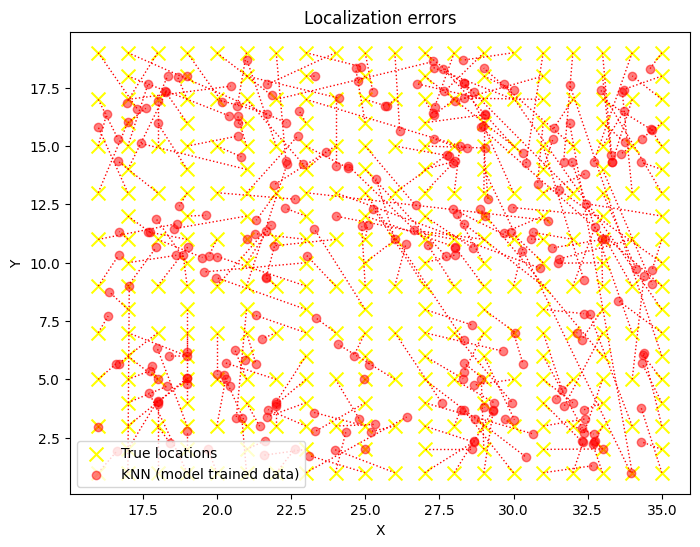

Y_rss.shape: (36, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5138
[TableDiffusion] Epoch 10/4000 - loss: 0.4941
[TableDiffusion] Epoch 20/4000 - loss: 0.4900
[TableDiffusion] Epoch 30/4000 - loss: 0.4891
[TableDiffusion] Epoch 40/4000 - loss: 0.4947
[TableDiffusion] Epoch 50/4000 - loss: 0.4861
[TableDiffusion] Epoch 60/4000 - loss: 0.4739
[TableDiffusion] Epoch 70/4000 - loss: 0.4630
[TableDiffusion] Epoch 80/4000 - loss: 0.4397
[TableDiffusion] Epoch 90/4000 - loss: 0.4486
[TableDiffusion] Epoch 100/4000 - loss: 0.4159
[TableDiffusion] Epoch 110/4000 - loss: 0.4555
[TableDiffusion] Epoch 120/4000 - loss: 0.3673
[TableDiffusion] Epoch 130/4000 - loss: 0.5130
[TableDiffusion] Epoch 140/4000 - loss: 0.4375
[TableDiffusion] Epoch 150/4000 - loss: 0.3955
[TableDiffusion] Epoch 160/4000 - loss: 0.6886
[TableDiffusion] Epoch 170/4000 - loss: 0.3996
[TableDiffusion] Epoch 180/4000 - loss: 0.3550
[TableDiffusion] Epoch 190/4000 - loss: 0.3152
[TableDiffusion] Epoch 200/4000 - lo

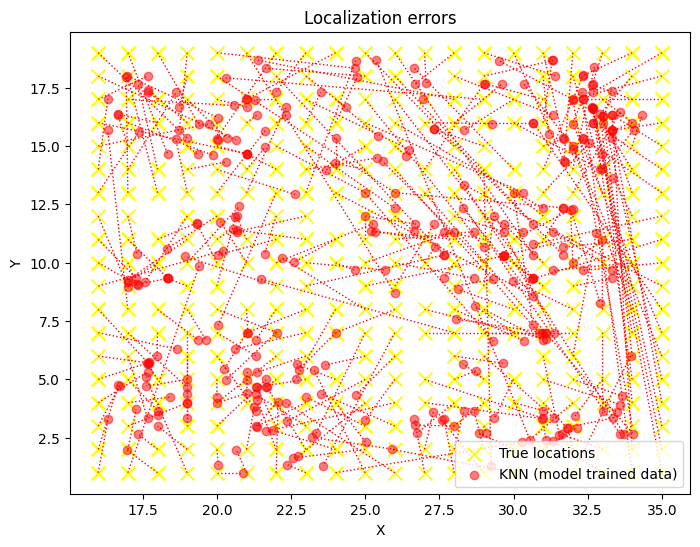

Y_rss.shape: (20, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.4980
[TableDiffusion] Epoch 10/4000 - loss: 0.4954
[TableDiffusion] Epoch 20/4000 - loss: 0.4911
[TableDiffusion] Epoch 30/4000 - loss: 0.4933
[TableDiffusion] Epoch 40/4000 - loss: 0.4859
[TableDiffusion] Epoch 50/4000 - loss: 0.4916
[TableDiffusion] Epoch 60/4000 - loss: 0.4762
[TableDiffusion] Epoch 70/4000 - loss: 0.4579
[TableDiffusion] Epoch 80/4000 - loss: 0.4721
[TableDiffusion] Epoch 90/4000 - loss: 0.4450
[TableDiffusion] Epoch 100/4000 - loss: 0.4185
[TableDiffusion] Epoch 110/4000 - loss: 0.3984
[TableDiffusion] Epoch 120/4000 - loss: 0.5333
[TableDiffusion] Epoch 130/4000 - loss: 0.4577
[TableDiffusion] Epoch 140/4000 - loss: 0.4315
[TableDiffusion] Epoch 150/4000 - loss: 0.3890
[TableDiffusion] Epoch 160/4000 - loss: 0.5753
[TableDiffusion] Epoch 170/4000 - loss: 0.4326
[TableDiffusion] Epoch 180/4000 - loss: 0.3853
[TableDiffusion] Epoch 190/4000 - loss: 0.3364
[TableDiffusion] Epoch 200/4000 - lo

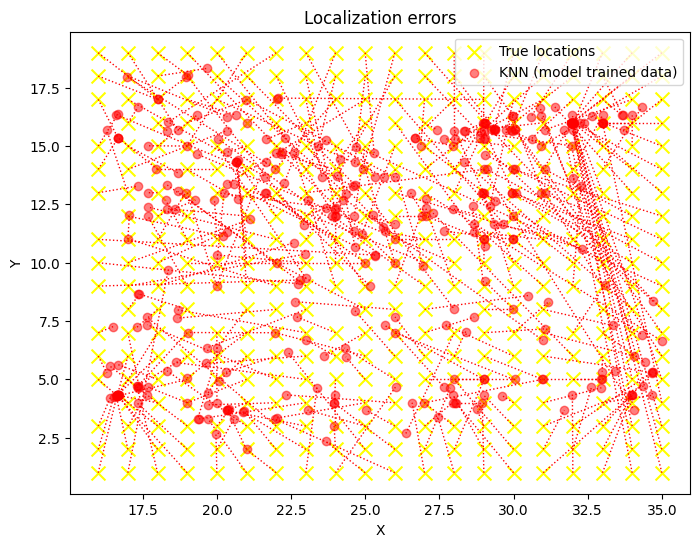

Y_rss.shape: (12, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5073
[TableDiffusion] Epoch 10/4000 - loss: 0.5027
[TableDiffusion] Epoch 20/4000 - loss: 0.4985
[TableDiffusion] Epoch 30/4000 - loss: 0.4959
[TableDiffusion] Epoch 40/4000 - loss: 0.4878
[TableDiffusion] Epoch 50/4000 - loss: 0.4896
[TableDiffusion] Epoch 60/4000 - loss: 0.4748
[TableDiffusion] Epoch 70/4000 - loss: 0.4774
[TableDiffusion] Epoch 80/4000 - loss: 0.4870
[TableDiffusion] Epoch 90/4000 - loss: 0.4418
[TableDiffusion] Epoch 100/4000 - loss: 0.4919
[TableDiffusion] Epoch 110/4000 - loss: 0.4549
[TableDiffusion] Epoch 120/4000 - loss: 0.6338
[TableDiffusion] Epoch 130/4000 - loss: 0.4227
[TableDiffusion] Epoch 140/4000 - loss: 0.4223
[TableDiffusion] Epoch 150/4000 - loss: 0.3808
[TableDiffusion] Epoch 160/4000 - loss: 0.5558
[TableDiffusion] Epoch 170/4000 - loss: 0.3936
[TableDiffusion] Epoch 180/4000 - loss: 0.3271
[TableDiffusion] Epoch 190/4000 - loss: 0.3664
[TableDiffusion] Epoch 200/4000 - lo

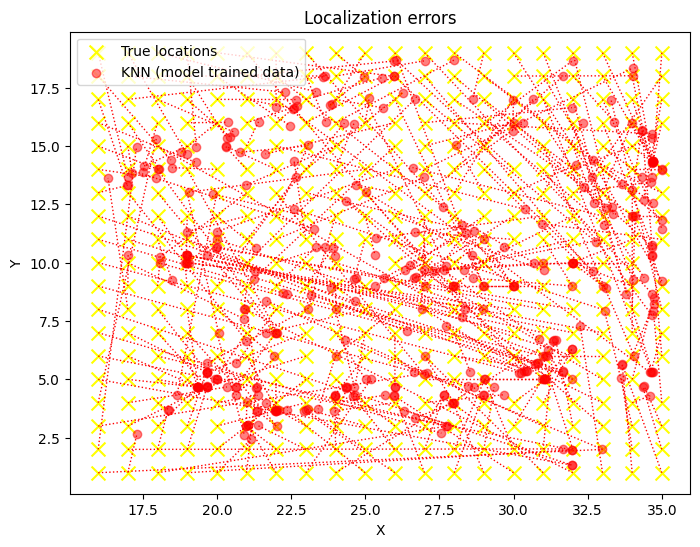

In [26]:
evaluate_tdm_prediction(
    split_every_2nd.median_knn_split[0],
    split_every_2nd.median_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_3rd.median_knn_split[0],
    split_every_3rd.median_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_4th.median_knn_split[0],
    split_every_4th.median_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_5th.median_knn_split[0],
    split_every_5th.median_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)


Y_rss.shape: (90, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5306
[TableDiffusion] Epoch 10/4000 - loss: 0.4854
[TableDiffusion] Epoch 20/4000 - loss: 0.4799
[TableDiffusion] Epoch 30/4000 - loss: 0.4625
[TableDiffusion] Epoch 40/4000 - loss: 0.4456
[TableDiffusion] Epoch 50/4000 - loss: 0.4009
[TableDiffusion] Epoch 60/4000 - loss: 0.3654
[TableDiffusion] Epoch 70/4000 - loss: 0.3567
[TableDiffusion] Epoch 80/4000 - loss: 0.3372
[TableDiffusion] Epoch 90/4000 - loss: 0.2448
[TableDiffusion] Epoch 100/4000 - loss: 0.2205
[TableDiffusion] Epoch 110/4000 - loss: 0.1988
[TableDiffusion] Epoch 120/4000 - loss: 0.1703
[TableDiffusion] Epoch 130/4000 - loss: 0.1574
[TableDiffusion] Epoch 140/4000 - loss: 0.1496
[TableDiffusion] Epoch 150/4000 - loss: 0.1480
[TableDiffusion] Epoch 160/4000 - loss: 0.1476
[TableDiffusion] Epoch 170/4000 - loss: 0.1392
[TableDiffusion] Epoch 180/4000 - loss: 0.1360
[TableDiffusion] Epoch 190/4000 - loss: 0.1453
[TableDiffusion] Epoch 200/4000 - lo

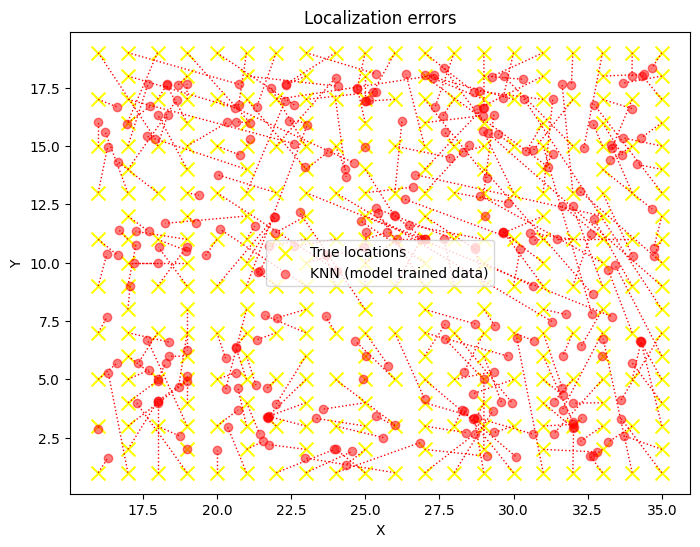

Y_rss.shape: (36, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5037
[TableDiffusion] Epoch 10/4000 - loss: 0.4959
[TableDiffusion] Epoch 20/4000 - loss: 0.4944
[TableDiffusion] Epoch 30/4000 - loss: 0.4921
[TableDiffusion] Epoch 40/4000 - loss: 0.4896
[TableDiffusion] Epoch 50/4000 - loss: 0.4804
[TableDiffusion] Epoch 60/4000 - loss: 0.4856
[TableDiffusion] Epoch 70/4000 - loss: 0.4567
[TableDiffusion] Epoch 80/4000 - loss: 0.4585
[TableDiffusion] Epoch 90/4000 - loss: 0.5262
[TableDiffusion] Epoch 100/4000 - loss: 0.4133
[TableDiffusion] Epoch 110/4000 - loss: 0.4297
[TableDiffusion] Epoch 120/4000 - loss: 0.4303
[TableDiffusion] Epoch 130/4000 - loss: 0.3658
[TableDiffusion] Epoch 140/4000 - loss: 0.4088
[TableDiffusion] Epoch 150/4000 - loss: 0.3990
[TableDiffusion] Epoch 160/4000 - loss: 0.3391
[TableDiffusion] Epoch 170/4000 - loss: 0.3515
[TableDiffusion] Epoch 180/4000 - loss: 0.3276
[TableDiffusion] Epoch 190/4000 - loss: 0.3018
[TableDiffusion] Epoch 200/4000 - lo

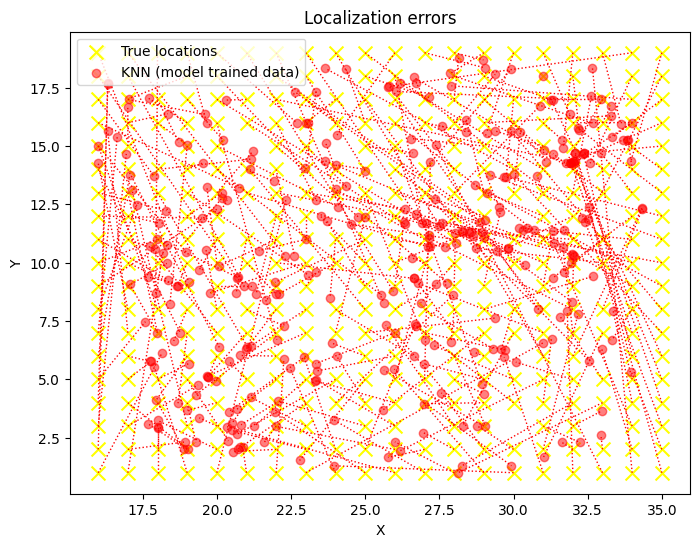

Y_rss.shape: (20, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5147
[TableDiffusion] Epoch 10/4000 - loss: 0.4886
[TableDiffusion] Epoch 20/4000 - loss: 0.4843
[TableDiffusion] Epoch 30/4000 - loss: 0.4844
[TableDiffusion] Epoch 40/4000 - loss: 0.4765
[TableDiffusion] Epoch 50/4000 - loss: 0.4693
[TableDiffusion] Epoch 60/4000 - loss: 0.4625
[TableDiffusion] Epoch 70/4000 - loss: 0.4447
[TableDiffusion] Epoch 80/4000 - loss: 0.4431
[TableDiffusion] Epoch 90/4000 - loss: 0.4484
[TableDiffusion] Epoch 100/4000 - loss: 0.4356
[TableDiffusion] Epoch 110/4000 - loss: 0.5434
[TableDiffusion] Epoch 120/4000 - loss: 0.4593
[TableDiffusion] Epoch 130/4000 - loss: 0.4591
[TableDiffusion] Epoch 140/4000 - loss: 0.4227
[TableDiffusion] Epoch 150/4000 - loss: 0.7126
[TableDiffusion] Epoch 160/4000 - loss: 0.3989
[TableDiffusion] Epoch 170/4000 - loss: 0.3661
[TableDiffusion] Epoch 180/4000 - loss: 0.3445
[TableDiffusion] Epoch 190/4000 - loss: 0.3801
[TableDiffusion] Epoch 200/4000 - lo

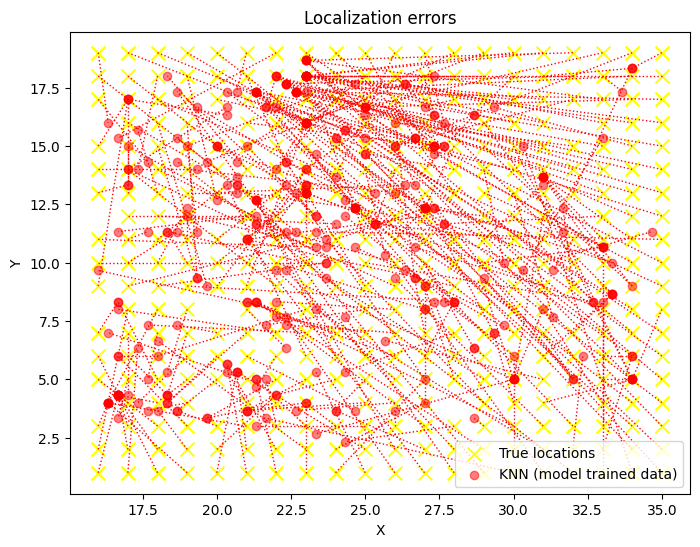

Y_rss.shape: (12, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5099
[TableDiffusion] Epoch 10/4000 - loss: 0.4995
[TableDiffusion] Epoch 20/4000 - loss: 0.4945
[TableDiffusion] Epoch 30/4000 - loss: 0.4892
[TableDiffusion] Epoch 40/4000 - loss: 0.4854
[TableDiffusion] Epoch 50/4000 - loss: 0.4938
[TableDiffusion] Epoch 60/4000 - loss: 0.4750
[TableDiffusion] Epoch 70/4000 - loss: 0.4590
[TableDiffusion] Epoch 80/4000 - loss: 0.4406
[TableDiffusion] Epoch 90/4000 - loss: 0.4526
[TableDiffusion] Epoch 100/4000 - loss: 0.4236
[TableDiffusion] Epoch 110/4000 - loss: 0.4130
[TableDiffusion] Epoch 120/4000 - loss: 0.4363
[TableDiffusion] Epoch 130/4000 - loss: 0.4115
[TableDiffusion] Epoch 140/4000 - loss: 0.4056
[TableDiffusion] Epoch 150/4000 - loss: 0.3947
[TableDiffusion] Epoch 160/4000 - loss: 0.3481
[TableDiffusion] Epoch 170/4000 - loss: 0.3749
[TableDiffusion] Epoch 180/4000 - loss: 0.3743
[TableDiffusion] Epoch 190/4000 - loss: 0.3159
[TableDiffusion] Epoch 200/4000 - lo

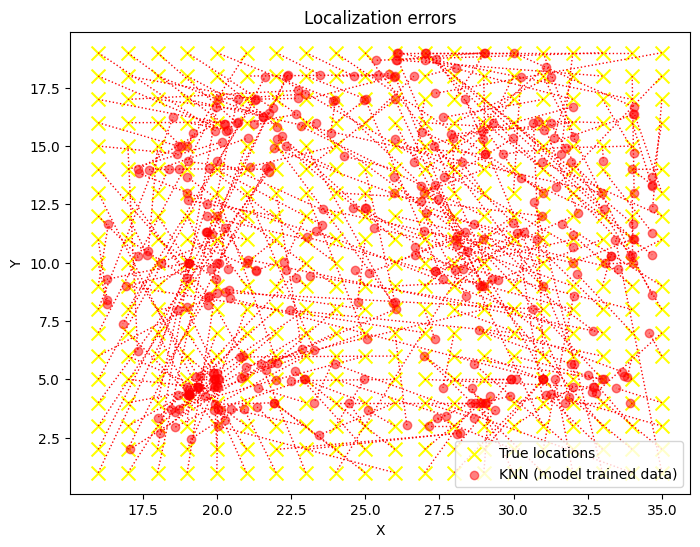

In [27]:
evaluate_tdm_prediction(
    split_every_2nd.mean_IDW_split[0],
    split_every_2nd.mean_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_3rd.mean_IDW_split[0],
    split_every_3rd.mean_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_4th.mean_IDW_split[0],
    split_every_4th.mean_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_5th.mean_IDW_split[0],
    split_every_5th.mean_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)


Y_rss.shape: (90, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5331
[TableDiffusion] Epoch 10/4000 - loss: 0.4959
[TableDiffusion] Epoch 20/4000 - loss: 0.4874
[TableDiffusion] Epoch 30/4000 - loss: 0.4730
[TableDiffusion] Epoch 40/4000 - loss: 0.4507
[TableDiffusion] Epoch 50/4000 - loss: 0.4195
[TableDiffusion] Epoch 60/4000 - loss: 0.4633
[TableDiffusion] Epoch 70/4000 - loss: 0.4852
[TableDiffusion] Epoch 80/4000 - loss: 0.3764
[TableDiffusion] Epoch 90/4000 - loss: 0.3763
[TableDiffusion] Epoch 100/4000 - loss: 0.3337
[TableDiffusion] Epoch 110/4000 - loss: 0.2822
[TableDiffusion] Epoch 120/4000 - loss: 0.2375
[TableDiffusion] Epoch 130/4000 - loss: 0.2556
[TableDiffusion] Epoch 140/4000 - loss: 0.2344
[TableDiffusion] Epoch 150/4000 - loss: 0.1912
[TableDiffusion] Epoch 160/4000 - loss: 0.1748
[TableDiffusion] Epoch 170/4000 - loss: 0.1659
[TableDiffusion] Epoch 180/4000 - loss: 0.1559
[TableDiffusion] Epoch 190/4000 - loss: 0.1600
[TableDiffusion] Epoch 200/4000 - lo

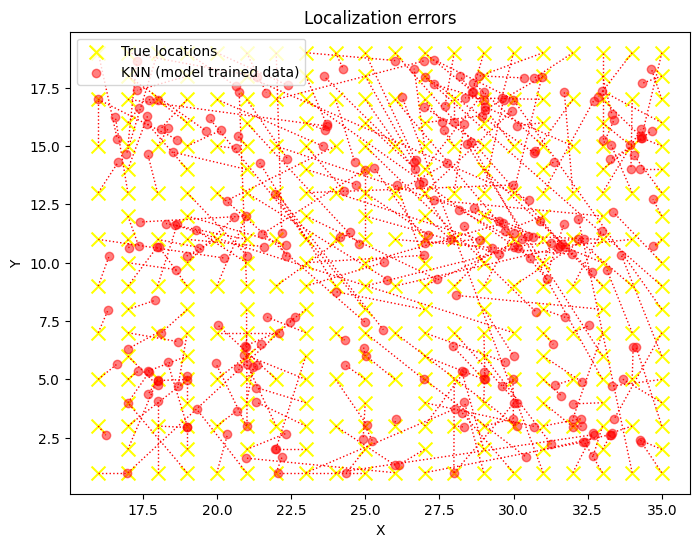

Y_rss.shape: (36, 18)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5173
[TableDiffusion] Epoch 10/4000 - loss: 0.4950
[TableDiffusion] Epoch 20/4000 - loss: 0.4952
[TableDiffusion] Epoch 30/4000 - loss: 0.4934
[TableDiffusion] Epoch 40/4000 - loss: 0.4851
[TableDiffusion] Epoch 50/4000 - loss: 0.4705
[TableDiffusion] Epoch 60/4000 - loss: 0.4522
[TableDiffusion] Epoch 70/4000 - loss: 0.4418
[TableDiffusion] Epoch 80/4000 - loss: 0.4587
[TableDiffusion] Epoch 90/4000 - loss: 0.4373
[TableDiffusion] Epoch 100/4000 - loss: 0.4155
[TableDiffusion] Epoch 110/4000 - loss: 0.4554
[TableDiffusion] Epoch 120/4000 - loss: 0.4024
[TableDiffusion] Epoch 130/4000 - loss: 0.4194
[TableDiffusion] Epoch 140/4000 - loss: 0.4133
[TableDiffusion] Epoch 150/4000 - loss: 0.3762
[TableDiffusion] Epoch 160/4000 - loss: 0.4279
[TableDiffusion] Epoch 170/4000 - loss: 0.3356
[TableDiffusion] Epoch 180/4000 - loss: 0.3456
[TableDiffusion] Epoch 190/4000 - loss: 0.3635
[TableDiffusion] Epoch 200/4000 - lo

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
14 fits failed out of a total of 21.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
14 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_regression.py", line 222, in fit
    return self._fit(X, y)
 

ValueError: Input X contains NaN.
KNeighborsRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [28]:
evaluate_tdm_prediction(
    split_every_2nd.median_IDW_split[0],
    split_every_2nd.median_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_3rd.median_IDW_split[0],
    split_every_3rd.median_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_4th.median_IDW_split[0],
    split_every_4th.median_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_5th.median_IDW_split[0],
    split_every_5th.median_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)
